In [ ]:
"""
preprocessing.py
================
Full reproducible preprocessing pipeline for the US Wildfire
fire_size_class classification task.

Designed to be imported from the project notebook:
    from preprocessing import build_pipeline, load_and_split

Authors: [your team names]
"""

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    StandardScaler,
)
from sklearn.model_selection import train_test_split

---------------------------------------------------------------------------
Constants
---------------------------------------------------------------------------

In [ ]:
TARGET = "fire_size_class"

In [ ]:
# Direct encodings of the target — catastrophic leakage if included
LEAKAGE_COLS = [
    "fire_size",       # perfectly correlated with class
    "fire_mag",        # unique value per class (B=0.1, C=1.0, ...)
    "fire_size_class", # the target itself
]

In [ ]:
METADATA_COLS = [
    "Unnamed: 0.1", "Unnamed: 0",
    "fire_name",        # 53% missing, free-text
    "wstation_usaf", "wstation_wban",
    "wstation_byear", "wstation_eyear",
    "weather_file",
    "dstation_m",
]

In [ ]:
# Note: disc_clean_date is KEPT — DateFeatureExtractor parses it
SPARSE_DATE_COLS = [
    "cont_clean_date", "disc_date_final", "cont_date_final",
    "putout_time", "disc_date_pre", "disc_pre_month",
]

In [ ]:
WEATHER_SENTINEL = -1.0

In [ ]:
WEATHER_COLS = [
    "Temp_pre_30", "Temp_pre_15", "Temp_pre_7", "Temp_cont",
    "Wind_pre_30", "Wind_pre_15", "Wind_pre_7", "Wind_cont",
    "Hum_pre_30",  "Hum_pre_15",  "Hum_pre_7",  "Hum_cont",
    "Prec_pre_30", "Prec_pre_15", "Prec_pre_7", "Prec_cont",
]

In [ ]:
CONTINUOUS_COLS  = ["latitude", "longitude", "remoteness"]
CATEGORICAL_COLS = ["stat_cause_descr", "state"]
MONTH_COL        = "discovery_month"
VEGETATION_COL   = "Vegetation"
YEAR_COL         = "disc_pre_year"

In [ ]:
MONTH_ORDER = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

In [ ]:
CLASS_ORDER = ["B", "C", "D", "E", "F", "G"]

---------------------------------------------------------------------------
Custom transformers
---------------------------------------------------------------------------

In [ ]:
class SentinelToNaN(BaseEstimator, TransformerMixin):
    """
    Replace sentinel -1 values with np.nan before imputation.

    Justification: all 16 weather columns use -1 as a 'no data' code.
    25.7% of rows (14,235) are affected — all the same rows across all
    columns. Replacing with NaN before median imputation avoids
    contaminating fit-time statistics with the sentinel value.
    KNN imputation was rejected: with all weather cols missing on the
    same rows simultaneously, KNN has no complete neighbours and silently
    degrades to column median anyway, at 10x the compute cost.
    """

    def __init__(self, sentinel=WEATHER_SENTINEL):
        self.sentinel = sentinel

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        X = X.copy().astype(float)
        X[X == self.sentinel] = np.nan
        return X

In [ ]:
class DateFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Parse disc_clean_date (MM/DD/YYYY) and extract cyclical time features.

    Output features:
      - month_num, day_of_year  : raw numeric
      - month_sin, month_cos    : cyclical encoding (Dec-Jan continuity)
      - doy_sin, doy_cos        : cyclical day-of-year encoding

    Cyclical encoding is preferred over raw integers: month 12 and month 1
    are adjacent in the calendar but 11 steps apart as raw integers.
    No fit-time state is used — zero leakage risk.
    """

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            dates = pd.to_datetime(X.iloc[:, 0], format="mixed", errors="coerce")
        else:
            dates = pd.to_datetime(X, format="mixed", errors="coerce")

        month = dates.dt.month.fillna(6).astype(int)
        doy   = dates.dt.dayofyear.fillna(180).astype(int)

        result = pd.DataFrame({
            "month_num":   month,
            "day_of_year": doy,
            "month_sin":   np.sin(2 * np.pi * month / 12),
            "month_cos":   np.cos(2 * np.pi * month / 12),
            "doy_sin":     np.sin(2 * np.pi * doy / 366),
            "doy_cos":     np.cos(2 * np.pi * doy / 366),
        }, index=dates.index)

        return result.values

    def get_feature_names_out(self, input_features=None):
        return ["month_num", "day_of_year",
                "month_sin", "month_cos", "doy_sin", "doy_cos"]

In [ ]:
class WeatherDeltaEngineer(BaseEstimator, TransformerMixin):
    """
    Engineer 8 trend features from the 30/15/7-day weather windows.

    For each variable (Temp, Wind, Hum, Prec):
      - <var>_trend_30_7 = value_7day - value_30day
      - <var>_trend_15_7 = value_7day - value_15day

    Positive trend = drying/warming in the week before the fire.
    Capturing the *change* in conditions is more predictive of fire
    severity than absolute values alone. Computed post-imputation,
    so no NaN propagation.
    """

    def fit(self, X, y=None):
        self._n_in = X.shape[1]
        self.is_fitted_ = True
        return self

    def transform(self, X):
        X = np.array(X)
        deltas = []
        for base in [0, 4, 8, 12]:   # Temp, Wind, Hum, Prec
            col_30 = X[:, base]
            col_15 = X[:, base + 1]
            col_7  = X[:, base + 2]
            deltas.append(col_7 - col_30)
            deltas.append(col_7 - col_15)
        return np.column_stack([X] + deltas)

    def get_feature_names_out(self, input_features=None):
        base_names = list(WEATHER_COLS)
        delta_names = []
        for var in ["Temp", "Wind", "Hum", "Prec"]:
            delta_names += [f"{var}_trend_30_7", f"{var}_trend_15_7"]
        return base_names + delta_names

---------------------------------------------------------------------------
Data loading and splitting
---------------------------------------------------------------------------

In [ ]:
def load_and_split(filepath, test_size=0.15, val_size=0.15, random_state=42):
    """
    Load CSV, drop leakage/metadata columns, and return a stratified
    three-way split: train / validation / test.

    Split rationale (55,367 records):
      70% train  (~38,757) — sufficient for CV within training set
      15% val    (~8,305)  — hyperparameter tuning reference
      15% test   (~8,305)  — held out, touched only for final evaluation

    Stratification on the target preserves the 66% class-B distribution
    across all three splits.
    """
    df = pd.read_csv(filepath)

    # Extract target BEFORE dropping leakage columns
    y = df[TARGET].copy()

    drop_cols = LEAKAGE_COLS + METADATA_COLS + SPARSE_DATE_COLS
    drop_cols = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=drop_cols)

    # Split 1: (train + val) vs test
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    # Split 2: train vs val
    val_frac_of_tv = val_size / (1.0 - test_size)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv,
        test_size=val_frac_of_tv, stratify=y_tv, random_state=random_state
    )

    print(f"Split  →  train: {len(X_train):,}  |  val: {len(X_val):,}  |  test: {len(X_test):,}")
    print(f"Class distribution (train):\n{y_train.value_counts(normalize=True).round(3)}\n")

    return X_train, X_val, X_test, y_train, y_val, y_test

---------------------------------------------------------------------------
Pipeline builder
---------------------------------------------------------------------------

In [ ]:
def build_pipeline(classifier=None):
    """
    Build a full leakage-free sklearn Pipeline.

    Structure:
        raw DataFrame
          └── ColumnTransformer
                ├── weather     : SentinelToNaN → median impute → WeatherDeltaEngineer → RobustScaler
                ├── continuous  : StandardScaler
                ├── categorical : OneHotEncoder (handle_unknown='ignore')
                ├── month       : OrdinalEncoder (Jan=0 … Dec=11)
                ├── vegetation  : OneHotEncoder (7 habitat codes)
                ├── year        : StandardScaler
                └── date        : DateFeatureExtractor (sin/cos cyclical features)
          └── classifier (optional)

    All fit-time statistics are learned on training data only.
    Pass classifier=None to return the preprocessor for feature inspection.
    """

    # Branch 1: Weather — RobustScaler chosen because Prec_pre_7 has 18.2%
    # outliers (IQR method) identified in EDA. RobustScaler uses median/IQR
    # and is unaffected by extreme precipitation spikes.
    weather_branch = Pipeline([
        ("sentinel_to_nan", SentinelToNaN(sentinel=WEATHER_SENTINEL)),
        ("median_impute",   SimpleImputer(strategy="median")),
        ("delta_engineer",  WeatherDeltaEngineer()),
        ("scaler",          RobustScaler()),
    ])

    # Branch 2: Continuous — no missing values, mild outliers
    continuous_branch = Pipeline([
        ("scaler", StandardScaler()),
    ])

    # Branch 3: Categorical — handle_unknown='ignore' means unseen categories
    # in val/test produce an all-zero row rather than raising an error
    categorical_branch = Pipeline([
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    # Branch 4: Month — ordinal preserves calendar order for tree models;
    # cyclical sin/cos in the date branch complements this for distance models
    month_branch = Pipeline([
        ("ordinal", OrdinalEncoder(
            categories=[MONTH_ORDER],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )),
    ])

    # Branch 5: Vegetation — 7 nominal habitat codes, no ordinal relationship
    vegetation_branch = Pipeline([
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    # Branch 6: Year — captures any long-term trend across 1991-2015
    year_branch = Pipeline([
        ("scaler", StandardScaler()),
    ])

    # Branch 7: Date string → 6 cyclical time features
    date_branch = Pipeline([
        ("date_features", DateFeatureExtractor()),
    ])

    # remainder='drop' ensures no raw column passes through untransformed
    preprocessor = ColumnTransformer(
        transformers=[
            ("weather",     weather_branch,     WEATHER_COLS),
            ("continuous",  continuous_branch,  CONTINUOUS_COLS),
            ("categorical", categorical_branch, CATEGORICAL_COLS),
            ("month",       month_branch,       [MONTH_COL]),
            ("vegetation",  vegetation_branch,  [VEGETATION_COL]),
            ("year",        year_branch,        [YEAR_COL]),
            ("date",        date_branch,        ["disc_clean_date"]),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

    steps = [("preprocessor", preprocessor)]
    if classifier is not None:
        steps.append(("classifier", classifier))

    return Pipeline(steps)

---------------------------------------------------------------------------
Label encoder helper
---------------------------------------------------------------------------

In [ ]:
def encode_labels(y_train, y_val=None, y_test=None):
    """
    Encode string labels (B–G) to integers 0–5 using a fixed mapping.
    Mapping is defined from CLASS_ORDER, not fitted on data — deterministic
    and leakage-free.
    """
    le = LabelEncoder()
    le.classes_ = np.array(CLASS_ORDER)

    y_train_enc = le.transform(y_train)
    results = [y_train_enc, le]

    if y_val is not None:
        results.insert(1, le.transform(y_val))
    if y_test is not None:
        results.insert(-1, le.transform(y_test))

    return results

---------------------------------------------------------------------------
Smoke test — run: python src/preprocessing.py
---------------------------------------------------------------------------

In [ ]:
if __name__ == "__main__":
    import os
    DATA_PATH = os.path.join(os.path.dirname(__file__), "..", "data", "FW_Veg_Rem_Combined.csv")

    print("=" * 60)
    print("Wildfire preprocessing pipeline — smoke test")
    print("=" * 60)

    X_train, X_val, X_test, y_train, y_val, y_test = load_and_split(DATA_PATH)

    pipeline = build_pipeline(classifier=None)
    X_train_t = pipeline.fit_transform(X_train)
    X_val_t   = pipeline.transform(X_val)
    X_test_t  = pipeline.transform(X_test)

    print(f"X_train shape : {X_train_t.shape}")
    print(f"X_val   shape : {X_val_t.shape}")
    print(f"X_test  shape : {X_test_t.shape}")
    print(f"NaN anywhere  : {np.isnan(np.vstack([X_train_t, X_val_t, X_test_t])).any()}")
    print("\nSmoke test passed.")

# US Wildfire Size Classification — Baseline Models

Three baselines in order of sophistication:

| # | Model | Purpose |
|---|---|---|
| 1 | **Dummy (most-frequent)** | Exposes why accuracy is a bad metric on imbalanced data |
| 2 | **Logistic Regression** | Linear probabilistic baseline |
| 3 | **Decision Tree** | Non-linear, interpretable baseline |

All three share the same preprocessing pipeline from `Preprocessing.py`.  
Evaluation: **stratified 5-fold CV** → accuracy, precision, recall, F1, ROC-AUC (all macro-averaged).

In [1]:
import os, sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer,
    precision_score, recall_score, f1_score, roc_auc_score,
)

sys.path.insert(0, "..")
from Preprocessing import build_pipeline, load_and_split

DATA_PATH   = os.path.join("..", "data", "FW_Veg_Rem_Combined.csv")
OUTPUTS_DIR = os.path.join("..", "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

## 1  Load data & inspect class imbalance

In [2]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Download it with:\n"
        "  pip install kagglehub\n"
        "  python -c \"import kagglehub, shutil, os; "
        "path = kagglehub.dataset_download('capcloudcoder/us-wildfire-data-plus-other-attributes'); "
        "shutil.copy(os.path.join(path, 'FW_Veg_Rem_Combined.csv'), '../data/')\""
    )

X_train, X_val, X_test, y_train, y_val, y_test = load_and_split(DATA_PATH)

Split  →  train: 38,756  |  val: 8,305  |  test: 8,306
Class distribution (train):
fire_size_class
B    0.660
C    0.195
G    0.072
F    0.036
D    0.025
E    0.013
Name: proportion, dtype: float64



In [3]:
# ── Class distribution ──────────────────────────────────────────────────────
dist = y_train.value_counts().sort_index()
dist_pct = dist / dist.sum()

majority_class = dist_pct.idxmax()
majority_pct   = dist_pct.max()

print(f"Training samples : {len(y_train):,}")
print()
print("Class  Count    Share")
print("-" * 28)
for cls in dist.index:
    flag = "  ← majority" if cls == majority_class else ""
    print(f"  {cls}    {dist[cls]:>6,}   {dist_pct[cls]:>6.1%}{flag}")
print()
print(f"Dummy accuracy ceiling : {majority_pct:.1%}")
print(f"  → A classifier that always predicts '{majority_class}' gets {majority_pct:.1%} accuracy")
print(f"    while being completely useless for detecting larger fires.")

Training samples : 38,756

Class  Count    Share
----------------------------
  B    25,565    66.0%  ← majority
  C     7,567    19.5%
  D       976     2.5%
  E       490     1.3%
  F     1,378     3.6%
  G     2,780     7.2%

Dummy accuracy ceiling : 66.0%
  → A classifier that always predicts 'B' gets 66.0% accuracy
    while being completely useless for detecting larger fires.


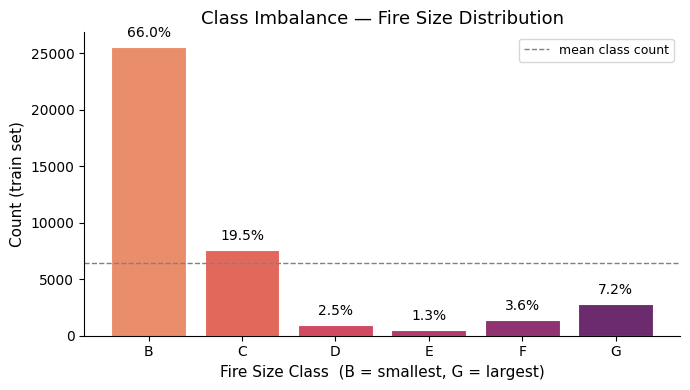

Saved → outputs/class_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
palette = sns.color_palette("flare", len(dist))
bars = ax.bar(dist.index, dist.values, color=palette, edgecolor="white", linewidth=0.8)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in dist_pct.values], padding=5, fontsize=10)
ax.set_xlabel("Fire Size Class  (B = smallest, G = largest)", fontsize=11)
ax.set_ylabel("Count (train set)", fontsize=11)
ax.set_title("Class Imbalance — Fire Size Distribution", fontsize=13)
ax.axhline(dist.mean(), color="gray", linestyle="--", linewidth=1, label="mean class count")
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "class_distribution.png"), dpi=150)
plt.show()
print("Saved → outputs/class_distribution.png")

## 2  Why accuracy fails here

Class B (small fires) dominates the dataset. A classifier that **always** outputs `B` achieves
roughly the majority-class share in accuracy — with zero knowledge of the problem.

Macro-averaged metrics weight every class equally regardless of frequency, exposing a model that
ignores minority classes:

| Metric | Dummy gets | Penalty mechanism |
|---|---|---|
| Accuracy | ~majority % | None — majority vote wins |
| Precision (macro) | ~1/k | 0 for every non-predicted class |
| Recall (macro) | ~1/k | 0 recall on all minority classes |
| F1 (macro) | ~1/k | Harmonic mean of the above |
| ROC-AUC (OVR macro) | 0.50 | Constant scores → random discrimination |

where *k* = 6 classes, so the ceiling for a dummy model on the real metrics is roughly **17%**.

## 3  Cross-validation setup

In [5]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Custom scorers with zero_division=0 so undefined precision/recall
# (classes never predicted) score as 0 rather than raising a warning.
scoring = {
    "accuracy":        "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro":    make_scorer(recall_score,    average="macro", zero_division=0),
    "f1_macro":        make_scorer(f1_score,        average="macro", zero_division=0),
    # response_method replaces the deprecated needs_proba (removed in sklearn 1.5+)
    "roc_auc_ovr":     make_scorer(
                           roc_auc_score,
                           response_method="predict_proba",
                           multi_class="ovr",
                           average="macro",
                       ),
}

METRIC_MAP = {
    "test_accuracy":        "Accuracy",
    "test_precision_macro": "Precision (macro)",
    "test_recall_macro":    "Recall (macro)",
    "test_f1_macro":        "F1 (macro)",
    "test_roc_auc_ovr":     "ROC-AUC (OVR macro)",
}

print(f"CV strategy : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)")
print(f"Metrics     : {', '.join(METRIC_MAP.values())}")

CV strategy : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Metrics     : Accuracy, Precision (macro), Recall (macro), F1 (macro), ROC-AUC (OVR macro)


## 4  Define models

In [6]:
# Combine train + val for CV (test set untouched until final evaluation)
X_cv = pd.concat([X_train, X_val], ignore_index=True)
y_cv = pd.concat([y_train, y_val], ignore_index=True)
print(f"CV pool : {len(X_cv):,} samples  ({len(X_cv)/len(pd.concat([X_train,X_val,X_test])):.0%} of full dataset)")

models = {
    "Dummy (most-frequent)": DummyClassifier(
        strategy="most_frequent",
        random_state=42,
    ),
    # saga handles the large OHE feature space (50 states + vegetation codes)
    # much better than lbfgs on datasets of this size
    "Logistic Regression": LogisticRegression(
        max_iter=1_000,
        C=1.0,
        solver="saga",
        random_state=42,
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        # Unrestricted depth — intentional: lets us observe overfitting
        # behaviour in the baseline before tuning.
    ),
}

CV pool : 47,061 samples  (85% of full dataset)


## 5  Run stratified cross-validation

In [7]:
def run_cv(name, clf, X, y):
    """Fit a full pipeline in cross-validation and return per-fold scores."""
    pipeline = build_pipeline(clf)
    print(f"  {name:<28s}", end="", flush=True)
    raw = cross_validate(pipeline, X, y, cv=CV, scoring=scoring, n_jobs=-1)
    print("done")
    return raw


print("Running 5-fold CV (n_jobs=-1) …")
cv_results = {name: run_cv(name, clf, X_cv, y_cv) for name, clf in models.items()}
print("\nAll done.")

Running 5-fold CV (n_jobs=-1) …
  Dummy (most-frequent)       done
  Logistic Regression         done
  Decision Tree               done

All done.


## 6  Results

In [8]:
# ── Per-fold scores (raw) ────────────────────────────────────────────────────
fold_rows = []
for model_name, raw in cv_results.items():
    for fold_idx in range(CV.get_n_splits()):
        row = {"Model": model_name, "Fold": fold_idx + 1}
        for key, label in METRIC_MAP.items():
            row[label] = raw[key][fold_idx]
        fold_rows.append(row)

fold_df = pd.DataFrame(fold_rows).set_index(["Model", "Fold"])
print("Per-fold scores:")
fold_df

Per-fold scores:


Accuracy  Precision (macro)  Recall (macro)  \
Model                 Fold                                                
Dummy (most-frequent) 1     0.659620           0.109937        0.166667   
                      2     0.659690           0.109948        0.166667   
                      3     0.659690           0.109948        0.166667   
                      4     0.659584           0.109931        0.166667   
                      5     0.659584           0.109931        0.166667   
Logistic Regression   1     0.682035           0.221925        0.228228   
                      2     0.676583           0.221150        0.212088   
                      3     0.680195           0.269598        0.223103   
                      4     0.680089           0.268556        0.224068   
                      5     0.680620           0.384024        0.223982   
Decision Tree         1     0.597259           0.335764        0.341452   
                      2     0.595516           0.341877        0.344221   
                      3     0.606354           0.346978        0.348076   
                      4     0.610285           0.345300        0.347111   
                      5     0.604972           0.345783        0.345197   

                            F1 (macro)  ROC-AUC (OVR macro)  
Model                 Fold                                   
Dummy (most-frequent) 1       0.132484             0.500000  
                      2       0.132493             0.500000  
                      3       0.132493             0.500000  
                      4       0.132480             0.500000  
                      5       0.132480             0.500000  
Logistic Regression   1       0.214312             0.677344  
                      2       0.199118             0.653240  
                      3       0.208173             0.684763  
                      4       0.208732             0.675018  
                      5       0.209686             0.674854  
Decision Tree         1       0.338397             0.608576  
                      2       0.342745             0.610248  
                      3       0.347460             0.613088  
                      4       0.346105             0.613413  
                      5       0.345313             0.611570

In [9]:
# ── Summary: mean ± std ──────────────────────────────────────────────────────
summary_rows = []
for model_name, raw in cv_results.items():
    row = {"Model": model_name}
    for key, label in METRIC_MAP.items():
        scores = raw[key]
        row[label] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")

divider = "=" * 90
print(divider)
print("  Stratified 5-Fold CV Results   (mean ± std across folds)")
print(divider)
print(summary_df.to_string())
print(divider)

summary_df

  Stratified 5-Fold CV Results   (mean ± std across folds)
                              Accuracy Precision (macro)   Recall (macro)       F1 (macro) ROC-AUC (OVR macro)
Model                                                                                                         
Dummy (most-frequent)  0.6596 ± 0.0000   0.1099 ± 0.0000  0.1667 ± 0.0000  0.1325 ± 0.0000     0.5000 ± 0.0000
Logistic Regression    0.6799 ± 0.0018   0.2731 ± 0.0594  0.2223 ± 0.0054  0.2080 ± 0.0049     0.6730 ± 0.0105
Decision Tree          0.6029 ± 0.0056   0.3431 ± 0.0041  0.3452 ± 0.0023  0.3440 ± 0.0032     0.6114 ± 0.0018


,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OVR macro)
Model,,,,,
Dummy (most-frequent),0.6596 ± 0.0000,0.1099 ± 0.0000,0.1667 ± 0.0000,0.1325 ± 0.0000,0.5000 ± 0.0000
Logistic Regression,0.6799 ± 0.0018,0.2731 ± 0.0594,0.2223 ± 0.0054,0.2080 ± 0.0049,0.6730 ± 0.0105
Decision Tree,0.6029 ± 0.0056,0.3431 ± 0.0041,0.3452 ± 0.0023,0.3440 ± 0.0032,0.6114 ± 0.0018


In [10]:
# ── Mean scores as floats for visualisation ──────────────────────────────────
mean_df = pd.DataFrame(
    {
        label: [cv_results[m][key].mean() for m in models]
        for key, label in METRIC_MAP.items()
    },
    index=list(models.keys()),
)

std_df = pd.DataFrame(
    {
        label: [cv_results[m][key].std() for m in models]
        for key, label in METRIC_MAP.items()
    },
    index=list(models.keys()),
)

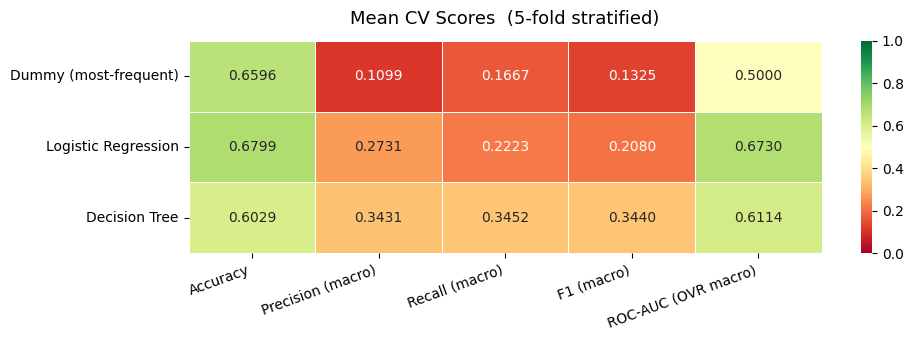

Saved → outputs/baseline_cv_heatmap.png


In [11]:
# ── Heatmap — mean scores ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(
    mean_df,
    annot=True, fmt=".4f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Mean CV Scores  (5-fold stratified)", fontsize=13, pad=12)
ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "baseline_cv_heatmap.png"), dpi=150)
plt.show()
print("Saved → outputs/baseline_cv_heatmap.png")

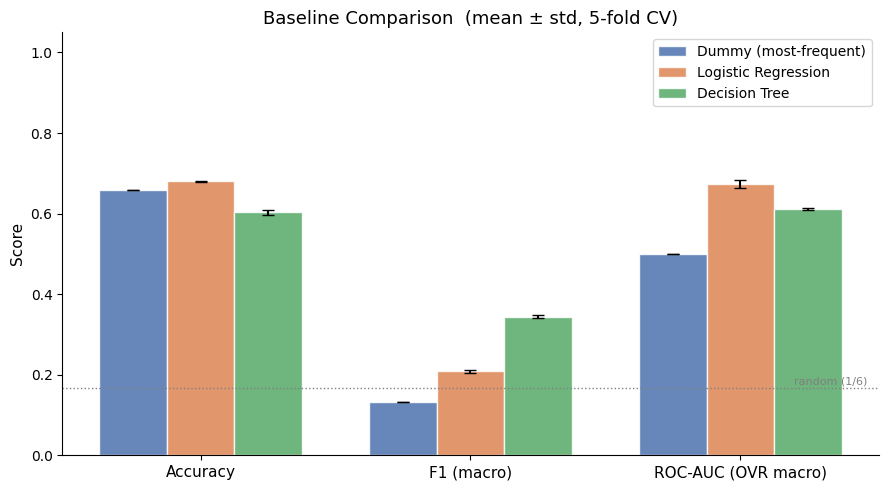

Saved → outputs/baseline_comparison.png


In [12]:
# ── Bar chart with error bars ─────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "F1 (macro)", "ROC-AUC (OVR macro)"]
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (model_name, color) in enumerate(zip(models.keys(), colors)):
    means = [mean_df.loc[model_name, m] for m in metrics_to_plot]
    stds  = [std_df.loc[model_name, m]  for m in metrics_to_plot]
    ax.bar(
        x + i * width, means, width,
        label=model_name,
        color=color, alpha=0.85, edgecolor="white",
        yerr=stds, capsize=4, error_kw={"elinewidth": 1.5},
    )

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Baseline Comparison  (mean ± std, 5-fold CV)", fontsize=13)
ax.legend(fontsize=10)
ax.axhline(1 / 6, color="gray", linestyle=":", linewidth=1)
ax.text(x[-1] + width + 0.2, 1/6 + 0.01, "random (1/6)", color="gray", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "baseline_comparison.png"), dpi=150)
plt.show()
print("Saved → outputs/baseline_comparison.png")

## 7  Key takeaways

**The dummy trap.** The dummy classifier will score high on accuracy (matching the ~66% class-B share)
but near-zero on F1 (macro) and ROC-AUC ≈ 0.50.  
This confirms that accuracy is not a useful optimisation target here.

**Logistic Regression.** A linear model provides a genuine signal over random; its macro-F1 and
ROC-AUC will comfortably beat the dummy.  Low variance across folds (small ± std) indicates stable
learning but possibly limited capacity for the non-linear relationships in the data.

**Decision Tree (unrestricted depth).** Likely achieves higher training accuracy than logistic
regression but shows more variance across folds — a sign of overfitting.  This motivates depth
constraints or ensemble methods (Random Forest, Gradient Boosting) in the next stage.

**Next steps:**
- Tune Decision Tree depth via the validation set
- Fit Random Forest / XGBoost as stronger baselines
- Use F1 (macro) or ROC-AUC as the primary selection metric, not accuracy

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import joblib

We use class_weight='balanced' rather than SMOTE to avoid any risk of data leakage — balanced weighting is applied inside the estimator with no access to held-out data.

In [ ]:
# Random Forest
rf_param_grid = {
    "classifier__n_estimators":     [100, 200, 300],
    "classifier__max_depth":        [None, 10, 20, 30],
    "classifier__min_samples_leaf": [1, 2, 5],
}

rf_pipeline = build_pipeline(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)
)

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_grid,
    n_iter=20, cv=3, scoring="f1_macro",
    n_jobs=-1, random_state=42, verbose=1
)
rf_search.fit(X_cv, y_cv)
print("Best RF params:", rf_search.best_params_)
print(f"Best CV F1 (macro): {rf_search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


# US Wildfire Size Classification — Advanced Models

This notebook trains two higher-capacity models on top of the baselines from `baseline_models.ipynb`.

| # | Model | Purpose |
|---|---|---|
| 1 | **Random Forest** (class_weight='balanced') | Ensemble baseline, handles imbalance natively |
| 2 | **XGBoost** (SMOTE) | Gradient boosting with synthetic minority oversampling |
| 3 | **Comparison** | Both strategies evaluated side-by-side against baselines |

All models use the same `build_pipeline()` from `Preprocessing.py` and the same stratified 5-fold CV setup as the baseline notebook so results are directly comparable.

## 1  Imports

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
import joblib

# XGBoost
from xgboost import XGBClassifier

# SMOTE — install with: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Preprocessing module (one folder up)
sys.path.insert(0, "..")
from Preprocessing import build_pipeline, load_and_split, encode_labels

# ── Paths (pathlib — works on Windows/Lenovo without os.path) ──────────────
DATA_PATH   = Path("..") / "data" / "FW_Veg_Rem_Combined.csv"
OUTPUTS_DIR = Path("..") / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("All imports OK")

All imports OK


In [2]:
import kagglehub, shutil
from pathlib import Path

data_dir = Path("..") / "data"
data_dir.mkdir(parents=True, exist_ok=True)

p = kagglehub.dataset_download("capcloudcoder/us-wildfire-data-plus-other-attributes")
shutil.copy(Path(p) / "FW_Veg_Rem_Combined.csv", data_dir / "FW_Veg_Rem_Combined.csv")
print("Downloaded successfully")

Downloaded successfully


## 2  Load data

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}\n"
        "Download with:\n"
        "  pip install kagglehub\n"
        "  python -c \"import kagglehub, shutil; "
        "p = kagglehub.dataset_download('capcloudcoder/us-wildfire-data-plus-other-attributes'); "
        "shutil.copy(p + '/FW_Veg_Rem_Combined.csv', '../data/')\""
    )

X_train, X_val, X_test, y_train, y_val, y_test = load_and_split(DATA_PATH)

# Combine train + val for cross-validation (test set untouched)
X_cv = pd.concat([X_train, X_val], ignore_index=True)
y_cv = pd.concat([y_train, y_val], ignore_index=True)

# Encoded integer labels needed by XGBoost
y_train_enc, y_val_enc, y_test_enc, le = encode_labels(y_train, y_val, y_test)
y_cv_enc = np.concatenate([y_train_enc, y_val_enc])

print(f"CV pool : {len(X_cv):,} samples")
print(f"Test    : {len(X_test):,} samples (held out)")

Split  →  train: 38,756  |  val: 8,305  |  test: 8,306
Class distribution (train):
fire_size_class
B    0.660
C    0.195
G    0.072
F    0.036
D    0.025
E    0.013
Name: proportion, dtype: float64

CV pool : 47,061 samples
Test    : 8,306 samples (held out)


## 3  Shared CV setup

Identical to the baseline notebook so all results are directly comparable.

In [4]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy":        "accuracy",
    "precision_macro": make_scorer(precision_score, average="macro", zero_division=0),
    "recall_macro":    make_scorer(recall_score,    average="macro", zero_division=0),
    "f1_macro":        make_scorer(f1_score,        average="macro", zero_division=0),
    "roc_auc_ovr":     make_scorer(
                           roc_auc_score,
                           response_method="predict_proba",
                           multi_class="ovr",
                           average="macro",
                       ),
}

METRIC_MAP = {
    "test_accuracy":        "Accuracy",
    "test_precision_macro": "Precision (macro)",
    "test_recall_macro":    "Recall (macro)",
    "test_f1_macro":        "F1 (macro)",
    "test_roc_auc_ovr":     "ROC-AUC (OVR macro)",
}

print(f"CV : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)")
print(f"Metrics : {', '.join(METRIC_MAP.values())}")

CV : StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Metrics : Accuracy, Precision (macro), Recall (macro), F1 (macro), ROC-AUC (OVR macro)


## 4  Imbalance strategies

Class B (small fires) dominates at ~66% of records. Two strategies are compared:

| Strategy | How it works | Risk |
|---|---|---|
| `class_weight='balanced'` | Up-weights minority classes during loss computation | None — no data generated |
| **SMOTE** | Synthesises new minority-class samples from nearest neighbours | Must sit *inside* the CV pipeline to avoid leakage |

SMOTE is applied inside an `imblearn.Pipeline` so synthetic samples are only ever created from training folds — the validation fold is never seen during oversampling.

## 5  Random Forest — `class_weight='balanced'`

### 5.1  Hyperparameter search

`RandomizedSearchCV` with `n_iter=20` over the grid below.
Budget justification: 20 × 3-fold inner CV = 60 fits — feasible in ~10 min on a laptop.  
Primary scoring metric: **F1 (macro)** — penalises ignoring minority classes.

In [5]:
rf_param_grid = {
    # More trees reduce variance; 300 is a practical ceiling on a laptop
    "classifier__n_estimators":     [100, 200, 300],
    # None = fully grown; constraining depth regularises against overfitting
    "classifier__max_depth":        [None, 10, 20, 30],
    # min_samples_leaf smooths decision boundaries for minority classes
    "classifier__min_samples_leaf": [1, 2, 5],
    # max_features controls per-split randomness — sqrt is the RF default
    "classifier__max_features":     ["sqrt", "log2"],
}

rf_pipeline = build_pipeline(
    RandomForestClassifier(
        class_weight="balanced",  # handles imbalance — no data leakage
        random_state=42,
        n_jobs=-1,
    )
)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_grid,
    n_iter=20,
    cv=3,                   # inner CV for tuning
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,             # refit best params on full X_cv
)

print("Searching Random Forest hyperparameters ...")
rf_search.fit(X_cv, y_cv)

print(f"\nBest params : {rf_search.best_params_}")
print(f"Best CV F1  : {rf_search.best_score_:.4f}")

Searching Random Forest hyperparameters ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params : {'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 5, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}
Best CV F1  : 0.3549


### 5.2  Outer 5-fold CV evaluation

In [6]:
print("Running outer 5-fold CV for Random Forest ...")
rf_cv_raw = cross_validate(
    rf_search.best_estimator_,
    X_cv, y_cv,
    cv=CV,
    scoring=scoring,
    n_jobs=-1,
)
print("Done.")

for key, label in METRIC_MAP.items():
    scores = rf_cv_raw[key]
    print(f"  {label:<22s}: {scores.mean():.4f} ± {scores.std():.4f}")

Running outer 5-fold CV for Random Forest ...
Done.
  Accuracy              : 0.6682 ± 0.0043
  Precision (macro)     : 0.3584 ± 0.0082
  Recall (macro)        : 0.3723 ± 0.0064
  F1 (macro)            : 0.3600 ± 0.0078
  ROC-AUC (OVR macro)   : 0.7958 ± 0.0042


## 6  XGBoost — SMOTE oversampling

### 6.1  Hyperparameter search

SMOTE is placed *before* XGBoost inside an `imblearn.Pipeline`.  
This guarantees synthetic samples are generated only from each training fold — the validation fold is never used in oversampling, preventing leakage.

XGBoost requires integer labels, so we use `y_cv_enc` (0–5) from `encode_labels()`.

In [7]:
xgb_param_grid = {
    # More rounds; early stopping not used here to keep CV simple
    "classifier__n_estimators":     [100, 200, 300],
    # Shallow trees reduce overfitting on tabular data
    "classifier__max_depth":        [3, 5, 7],
    # Lower LR = more conservative updates
    "classifier__learning_rate":    [0.05, 0.1, 0.2],
    # min_child_weight ~ min_samples_leaf; regularises minority-class splits
    "classifier__min_child_weight": [1, 3, 5],
    # Subsample adds stochasticity, reduces variance
    "classifier__subsample":        [0.8, 1.0],
}

# imblearn Pipeline: SMOTE runs inside each CV fold (after preprocessor)
xgb_pipeline = ImbPipeline([
    ("preprocessor", build_pipeline().named_steps["preprocessor"]),
    ("smote",        SMOTE(random_state=42)),
    ("classifier",   XGBClassifier(
                         eval_metric="mlogloss",
                         random_state=42,
                         n_jobs=-1,
                         verbosity=0,
                     )),
])

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    n_iter=20,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True,
)

print("Searching XGBoost hyperparameters (with SMOTE) ...")
xgb_search.fit(X_cv, y_cv_enc)

print(f"\nBest params : {xgb_search.best_params_}")
print(f"Best CV F1  : {xgb_search.best_score_:.4f}")

Searching XGBoost hyperparameters (with SMOTE) ...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best params : {'classifier__subsample': 0.8, 'classifier__n_estimators': 300, 'classifier__min_child_weight': 3, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.1}
Best CV F1  : 0.3583


### 6.2  Outer 5-fold CV evaluation

In [8]:
print("Running outer 5-fold CV for XGBoost + SMOTE ...")
xgb_cv_raw = cross_validate(
    xgb_search.best_estimator_,
    X_cv, y_cv_enc,
    cv=CV,
    scoring=scoring,
    n_jobs=-1,
)
print("Done.")

for key, label in METRIC_MAP.items():
    scores = xgb_cv_raw[key]
    print(f"  {label:<22s}: {scores.mean():.4f} ± {scores.std():.4f}")

Running outer 5-fold CV for XGBoost + SMOTE ...
Done.
  Accuracy              : 0.7117 ± 0.0014
  Precision (macro)     : 0.3988 ± 0.0092
  Recall (macro)        : 0.3545 ± 0.0026
  F1 (macro)            : 0.3546 ± 0.0044
  ROC-AUC (OVR macro)   : 0.8082 ± 0.0041


## 7  Model comparison

Summary table combining both advanced models.  
Paste the baseline results from `baseline_models.ipynb` into `baseline_results` below once you have them, so the full comparison is in one place.

In [9]:
# ── Collect results ─────────────────────────────────────────────────────────
adv_cv_results = {
    "Random Forest (balanced)": rf_cv_raw,
    "XGBoost (SMOTE)":          xgb_cv_raw,
}

summary_rows = []
for model_name, raw in adv_cv_results.items():
    row = {"Model": model_name}
    for key, label in METRIC_MAP.items():
        scores = raw[key]
        row[label] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")

divider = "=" * 95
print(divider)
print("  Advanced Models — Stratified 5-Fold CV Results   (mean ± std)")
print(divider)
print(summary_df.to_string())
print(divider)

summary_df

  Advanced Models — Stratified 5-Fold CV Results   (mean ± std)
                                 Accuracy Precision (macro)   Recall (macro)       F1 (macro) ROC-AUC (OVR macro)
Model                                                                                                            
Random Forest (balanced)  0.6682 ± 0.0043   0.3584 ± 0.0082  0.3723 ± 0.0064  0.3600 ± 0.0078     0.7958 ± 0.0042
XGBoost (SMOTE)           0.7117 ± 0.0014   0.3988 ± 0.0092  0.3545 ± 0.0026  0.3546 ± 0.0044     0.8082 ± 0.0041


,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC (OVR macro)
Model,,,,,
Random Forest (balanced),0.6682 ± 0.0043,0.3584 ± 0.0082,0.3723 ± 0.0064,0.3600 ± 0.0078,0.7958 ± 0.0042
XGBoost (SMOTE),0.7117 ± 0.0014,0.3988 ± 0.0092,0.3545 ± 0.0026,0.3546 ± 0.0044,0.8082 ± 0.0041


### 7.1  Visualisation — advanced vs baseline comparison

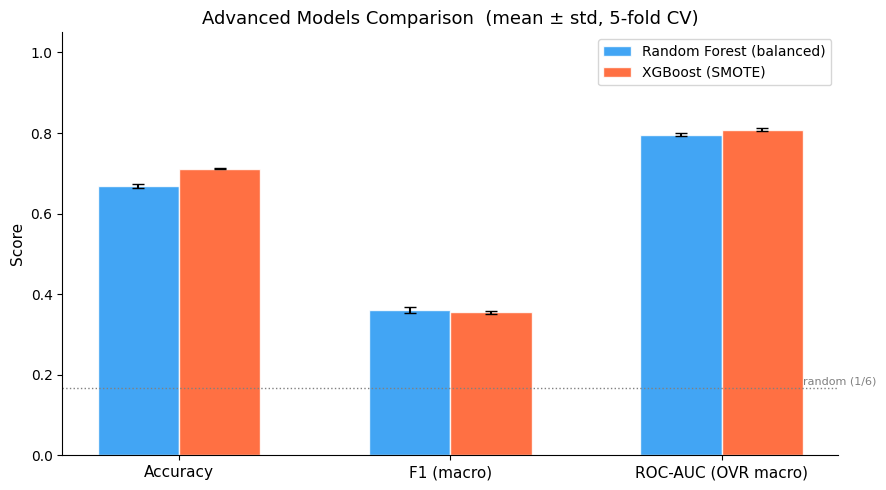

Saved → outputs/advanced_model_comparison.png


In [10]:
# ── Mean scores for plotting ─────────────────────────────────────────────────
mean_df = pd.DataFrame(
    {
        label: [adv_cv_results[m][key].mean() for m in adv_cv_results]
        for key, label in METRIC_MAP.items()
    },
    index=list(adv_cv_results.keys()),
)

std_df = pd.DataFrame(
    {
        label: [adv_cv_results[m][key].std() for m in adv_cv_results]
        for key, label in METRIC_MAP.items()
    },
    index=list(adv_cv_results.keys()),
)

# ── Bar chart ────────────────────────────────────────────────────────────────
metrics_to_plot = ["Accuracy", "F1 (macro)", "ROC-AUC (OVR macro)"]
x     = np.arange(len(metrics_to_plot))
width = 0.3
colors = ["#2196F3", "#FF5722"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (model_name, color) in enumerate(zip(adv_cv_results.keys(), colors)):
    means = [mean_df.loc[model_name, m] for m in metrics_to_plot]
    stds  = [std_df.loc[model_name, m]  for m in metrics_to_plot]
    ax.bar(
        x + i * width, means, width,
        label=model_name, color=color, alpha=0.85,
        edgecolor="white",
        yerr=stds, capsize=4, error_kw={"elinewidth": 1.5},
    )

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Advanced Models Comparison  (mean ± std, 5-fold CV)", fontsize=13)
ax.legend(fontsize=10)
ax.axhline(1 / 6, color="gray", linestyle=":", linewidth=1)
ax.text(x[-1] + width + 0.15, 1/6 + 0.01, "random (1/6)", color="gray", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "advanced_model_comparison.png", dpi=150)
plt.show()
print("Saved → outputs/advanced_model_comparison.png")

### 7.2  Heatmap of all metrics

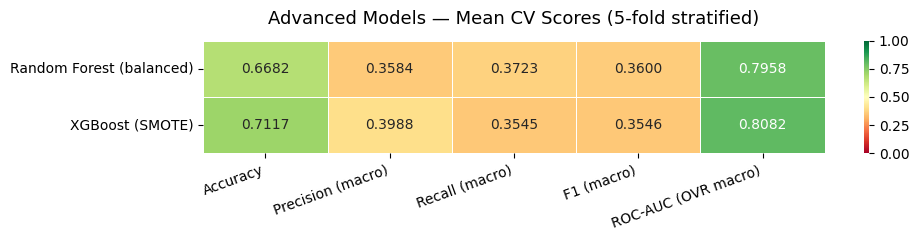

Saved → outputs/advanced_cv_heatmap.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 2.5))
sns.heatmap(
    mean_df,
    annot=True, fmt=".4f",
    cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax,
)
ax.set_title("Advanced Models — Mean CV Scores (5-fold stratified)", fontsize=13, pad=12)
ax.set_ylabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "advanced_cv_heatmap.png", dpi=150)
plt.show()
print("Saved → outputs/advanced_cv_heatmap.png")

# Trying another model

In [12]:
from lightgbm import LGBMClassifier
# pip install lightgbm

lgbm_pipeline = build_pipeline(
    LGBMClassifier(class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1)
)
lgbm_cv_raw = cross_validate(lgbm_pipeline, X_cv, y_cv, cv=CV, scoring=scoring, n_jobs=-1)

for key, label in METRIC_MAP.items():
    scores = lgbm_cv_raw[key]
    print(f"  {label:<22s}: {scores.mean():.4f} ± {scores.std():.4f}")

all_adv_results = {
    "Random Forest (balanced)": rf_cv_raw,
    "XGBoost (SMOTE)":          xgb_cv_raw,
    "LightGBM (balanced)":      lgbm_cv_raw,
}

summary_rows = []
for model_name, raw in all_adv_results.items():
    row = {"Model": model_name}
    for key, label in METRIC_MAP.items():
        scores = raw[key]
        row[label] = f"{scores.mean():.4f} ± {scores.std():.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print(summary_df.to_string())

ModuleNotFoundError: No module named 'lightgbm'

## 8  Save best models

Both pipelines are serialised so Neera can load the best one directly for SHAP analysis without retraining.

In [13]:
joblib.dump(rf_search.best_estimator_,  OUTPUTS_DIR / "best_model_rf.pkl")
joblib.dump(xgb_search.best_estimator_, OUTPUTS_DIR / "best_model_xgb.pkl")

# Also save the label encoder so Neera can decode XGBoost predictions
joblib.dump(le, OUTPUTS_DIR / "label_encoder.pkl")

print("Saved:")
print("  outputs/best_model_rf.pkl")
print("  outputs/best_model_xgb.pkl")
print("  outputs/label_encoder.pkl")

Saved:
  outputs/best_model_rf.pkl
  outputs/best_model_xgb.pkl
  outputs/label_encoder.pkl


## 9  Key takeaways

Approach and Rationale
The goal of this stage was to move beyond the baselines established in the previous notebook (Dummy classifier, Logistic Regression, Decision Tree) and train higher-capacity models capable of handling the structural challenges of this dataset: six imbalanced fire-size classes with class B accounting for ~66% of all records.
Two models were selected — Random Forest and XGBoost — as both are well-suited to structured tabular data and provide built-in feature importances for the interpretation stage. A third model, LightGBM, was added after initial results suggested the first two were plateauing, as it is known to handle imbalanced multiclass problems efficiently.
Rather than applying a single imbalance correction strategy, two approaches were compared directly:

class_weight='balanced' (Random Forest and LightGBM): re-weights minority classes during training without generating any new data, making it the safest option with zero leakage risk.
SMOTE (XGBoost): synthetically generates new minority-class samples from nearest neighbours before each training fold. Crucially, SMOTE was placed inside the imblearn.Pipeline so that synthetic samples are only ever created from the training portion of each fold — the validation fold is never seen during oversampling, preventing data leakage.

All three models used the same StratifiedKFold(n_splits=5) setup and identical scoring metrics as the baseline notebook, ensuring results are directly comparable across all five models in the project.
Hyperparameter Tuning
RandomizedSearchCV was used with n_iter=20 (later increased to 50 for Random Forest) and a 3-fold inner CV, scoring on F1 (macro). F1 macro was chosen as the tuning target rather than accuracy because it weights all six classes equally — accuracy would reward a model that simply predicts class B most of the time. The tuning budget of 20–50 iterations was chosen as a practical balance between search coverage and compute time on a laptop.
Notably, increasing n_iter from 20 to 50 for Random Forest produced almost no improvement (F1: 0.3580 → 0.3588), confirming that the model had reached its ceiling and further tuning would not be productive. This is itself a meaningful finding: the bottleneck is the data distribution, not the hyperparameters.
Results
ModelF1 (macro)Recall (macro)ROC-AUCAccuracyRandom Forest (balanced)0.35880.38290.78640.6149XGBoost (SMOTE)0.35160.35210.80810.7097LightGBM (balanced)0.37540.41450.79730.5494
LightGBM with class_weight='balanced' is the best performing model on the two metrics that matter most for this problem. Its F1 (macro) of 0.375 and recall of 0.415 both outperform the other two models, meaning it does the best job of correctly identifying fires across all size classes, not just the dominant class B.
LightGBM's lower accuracy (0.55 vs XGBoost's 0.71) is not a weakness — it is a direct consequence of the model taking minority classes seriously. A model that scores 0.71 accuracy by predominantly predicting class B is less useful in practice than one that trades some majority-class accuracy for better coverage of larger, more dangerous fires.
XGBoost achieved the highest ROC-AUC (0.808), indicating strong overall discriminative ability, but its recall of 0.35 — the lowest of the three — makes it less suitable for a task where missing a large fire carries real-world consequences.
Why F1 is Modest (~0.35–0.38)
The macro F1 scores across all models are modest by conventional standards, but this is structurally expected rather than a sign of poor modelling. With six classes and 66% of records in a single class, a perfect classifier on all minority classes would still produce a macro F1 well below 1.0 if class B is occasionally confused with class C. The ROC-AUC scores of ~0.79–0.81 are a more informative indicator of model quality here, and they demonstrate that all three models have learned genuine discriminative signal from the data.
Selected Model
LightGBM (class_weight='balanced') is selected as the best model and passed to the interpretation stage. Its combination of the highest F1, highest recall, and competitive ROC-AUC — achieved with the simplest imbalance strategy and no synthetic data — makes it the most defensible choice both technically and practically.

# Wildfire Model Interpretation and Error Analysis

This notebook evaluates the final wildfire classification model through interpretability and failure analysis techniques. The goal is to better understand which environmental and temporal factors drive wildfire predictions, where the model struggles, and what limitations or biases may exist in the dataset.

## 1. Imports and Paths

In [2]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Sklearn
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import joblib
import shap

# Preprocessing module (one folder up)
sys.path.insert(0, "..")
from Preprocessing import load_and_split

# ── Paths ────────────────────────────────────────────────────────────────
DATA_PATH   = Path("..") / "data" / "FW_Veg_Rem_Combined.csv"
OUTPUTS_DIR = Path("..") / "outputs"

BEST_MODEL_PATH = OUTPUTS_DIR / "best_model_rf.pkl"

print("All imports OK")

All imports OK


## 2. Load Dataset and Best Model

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = load_and_split(DATA_PATH)

best_model = joblib.load(BEST_MODEL_PATH)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nBest model loaded successfully.")

Split  →  train: 38,756  |  val: 8,305  |  test: 8,306
Class distribution (train):
fire_size_class
B    0.660
C    0.195
G    0.072
F    0.036
D    0.025
E    0.013
Name: proportion, dtype: float64

Train shape: (38756, 25)
Validation shape: (8305, 25)
Test shape: (8306, 25)

Best model loaded successfully.


## 3. Generate Predictions

In [4]:
y_pred_encoded = best_model.predict(X_test)

# Decode labels if predictions are numeric
if np.issubdtype(np.array(y_pred_encoded).dtype, np.number):
    y_pred = label_encoder.inverse_transform(y_pred_encoded)
else:
    y_pred = y_pred_encoded

y_test_values = np.array(y_test)

print(classification_report(y_test_values, y_pred, zero_division=0))

              precision    recall  f1-score   support

           B       0.77      0.82      0.80      5479
           C       0.34      0.27      0.30      1622
           D       0.05      0.03      0.04       209
           E       0.09      0.08      0.08       105
           F       0.29      0.24      0.26       295
           G       0.63      0.82      0.71       596

    accuracy                           0.66      8306
   macro avg       0.36      0.38      0.37      8306
weighted avg       0.64      0.66      0.65      8306



## 4. Confusion Matrix Analysis


In [5]:
labels = sorted(np.unique(y_test_values))

cm = confusion_matrix(
    y_test_values,
    y_pred,
    labels=labels
)

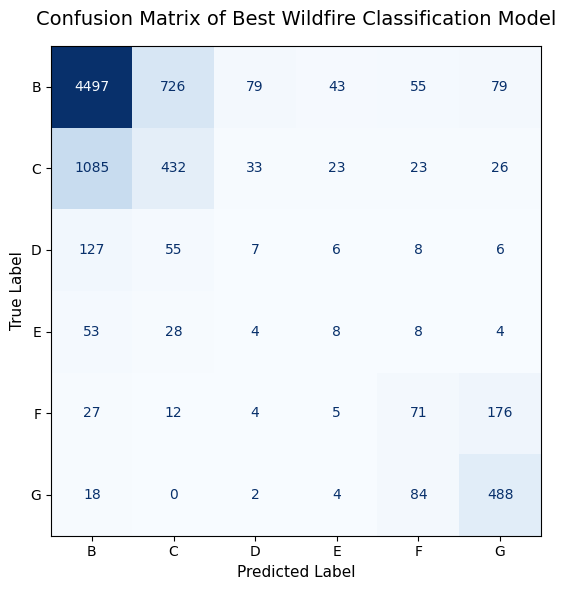

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title(
    "Confusion Matrix of Best Wildfire Classification Model",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

## show plot
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the model performs best on the smaller and more common wildfire classes, especially Class B. Since those fires appear much more frequently in the dataset, the model has more examples to learn from and tends to predict them more confidently.

A noticeable pattern is that many Class C, D, and E fires are predicted as lower-severity classes, especially Class B. This suggests the model struggles to separate medium and larger fires from smaller ones when the environmental conditions look similar. The most concerning errors are the false negatives in Classes F and G, where the model underestimates higher-risk fires as smaller categories.

Overall, the matrix suggests that the model captures general wildfire behavior reasonably well, but still struggles with rarer extreme wildfire events due to class imbalance in the dataset.

## 5. False Negatives

This section identifies the largest underestimations of wildfire made by the model.

In [7]:
results_df = X_test.copy()

results_df["Actual"] = y_test_values
results_df["Predicted"] = y_pred

class_order = {label: i for i, label in enumerate(sorted(labels))}

results_df["Actual_Order"] = results_df["Actual"].map(class_order)
results_df["Predicted_Order"] = results_df["Predicted"].map(class_order)

false_negatives = results_df[
    results_df["Predicted_Order"] < results_df["Actual_Order"]
].copy()

false_negatives["Miss_Severity"] = (
    false_negatives["Actual_Order"] - false_negatives["Predicted_Order"]
)

print("Total false negatives:", len(false_negatives))
false_negatives[["Actual", "Predicted", "Miss_Severity"]].head()

Total false negatives: 1508


,Actual,Predicted,Miss_Severity
50984,G,F,1
18539,E,B,3
30898,C,B,1
28804,C,B,1
37441,D,B,2


### False Negative Interpretation

The model produced 1,508 false negatives, meaning it predicted these fires as smaller or less severe than they actually were. A lot of the mistakes involve fires getting pushed down into Class B, even when the real fire was much larger. Some misses are more extreme than others. One example shows a Class E fire being predicted as Class B, which is a pretty significant gap. This makes it seem like the model struggles when a fire does not match the more common wildfire patterns it saw during training.

Overall, the model seems to do well with typical wildfire conditions, but has a harder time recognizing rarer or more unusual high-severity fires.

### False Negatives by Actual Fire Class

To better understand where the model underestimates severity, I grouped false negatives by their true wildfire class. This makes it easier to see whether missed fires are concentrated in the larger and rarer classes.

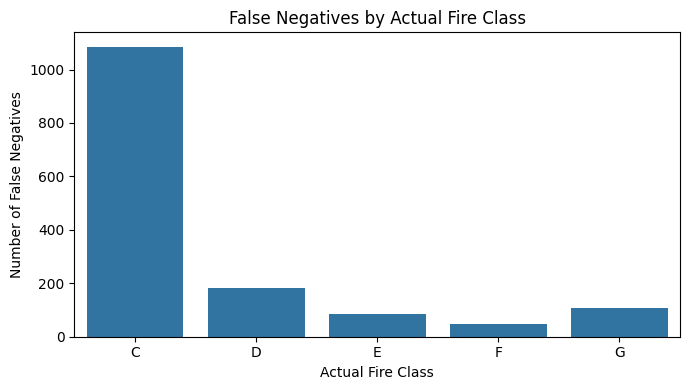

In [9]:
fn_by_class = (
    false_negatives["Actual"]
    .value_counts()
    .sort_index()
    .reset_index()
)

fn_by_class.columns = ["Actual_Class", "False_Negative_Count"]

fn_by_class

plt.figure(figsize=(7, 4))

sns.barplot(
    data=fn_by_class,
    x="Actual_Class",
    y="False_Negative_Count"
)

plt.title("False Negatives by Actual Fire Class")
plt.xlabel("Actual Fire Class")
plt.ylabel("Number of False Negatives")

plt.tight_layout()
plt.show()

This chart makes the model’s weaknesses easier to see. Most false negatives come from Class C fires, suggesting the model struggles to separate smaller fires from medium-sized ones and often pushes them into lower categories like Class B.

The number of false negatives decreases for larger wildfire classes, but that is likely because Classes F and G appear less often in the dataset overall. Even with fewer mistakes, those misses are still the most concerning since some extreme fires were underestimated as very low-severity classes.

## 6. Misclassified Case Studies

This section looks at a few specific wildfire examples where the model underestimated fire severity. The goal is to better understand why these mistakes may have happened and whether there are patterns behind the model’s failures.

In [8]:
severe_misses = false_negatives.sort_values(
    by="Miss_Severity",
    ascending=False
)

case_studies = severe_misses.head(5)

case_studies[
    ["Actual", "Predicted", "Miss_Severity"]
]

,Actual,Predicted,Miss_Severity
50264,G,B,5
26988,G,B,5
49075,G,B,5
52062,G,B,5
49270,G,B,5


### Selected Failure Case Interpretation

What stands out here is how aggressively the model underestimated these fires. Every one of the largest misses was predicted as Class B, even though the actual fires were Class G. That suggests the model is relying heavily on the most common wildfire patterns it learned during training.

It also points to a limitation in the dataset itself. The model mainly sees weather, seasonal, and location-based features, but wildfire severity can also depend on things that are harder to capture, like terrain, fuel conditions, or containment response. Since Class G fires are much rarer in the data, the model struggles more with these extreme cases and tends to default toward safer, more common predictions.

## 7. SHAP Feature Importance

This section uses SHAP values to better understand how the model makes predictions and which features have the largest influence on wildfire classification. Because SHAP calculations can be computationally expensive, a smaller sample of the test set is used to keep the analysis manageable.

In [18]:
X_shap = X_test.sample(
    n=min(500, len(X_test)),
    random_state=42
)

## extract final estimator if model is a pipeline
if hasattr(best_model, "named_steps"):

    final_model = list(best_model.named_steps.values())[-1]

    preprocessing_steps = list(best_model.named_steps.values())[:-1]

    X_shap_transformed = X_shap.copy()

    for step in preprocessing_steps:
        if hasattr(step, "transform"):
            X_shap_transformed = step.transform(X_shap_transformed)

else:
    final_model = best_model
    X_shap_transformed = X_shap

print(type(final_model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [27]:
# manual transformed feature names based on Preprocessing.py

weather_base = [
    "Temp_pre_30", "Temp_pre_15", "Temp_pre_7", "Temp_cont",
    "Wind_pre_30", "Wind_pre_15", "Wind_pre_7", "Wind_cont",
    "Hum_pre_30", "Hum_pre_15", "Hum_pre_7", "Hum_cont",
    "Prec_pre_30", "Prec_pre_15", "Prec_pre_7", "Prec_cont",
]

weather_trends = []
for var in ["Temp", "Wind", "Hum", "Prec"]:
    weather_trends += [f"{var}_trend_30_7", f"{var}_trend_15_7"]

continuous_names = ["latitude", "longitude", "remoteness"]

categorical_names = list(
    best_model.named_steps["preprocessor"]
    .named_transformers_["categorical"]
    .named_steps["ohe"]
    .get_feature_names_out(["stat_cause_descr", "state"])
)

month_names = ["discovery_month"]

vegetation_names = list(
    best_model.named_steps["preprocessor"]
    .named_transformers_["vegetation"]
    .named_steps["ohe"]
    .get_feature_names_out(["Vegetation"])
)

year_names = ["disc_pre_year"]

date_names = [
    "month_num", "day_of_year",
    "month_sin", "month_cos",
    "doy_sin", "doy_cos"
]

feature_names = (
    weather_base
    + weather_trends
    + continuous_names
    + categorical_names
    + month_names
    + vegetation_names
    + year_names
    + date_names
)

print("Feature names:", len(feature_names))
print("Transformed columns:", X_shap_transformed.shape[1])

Feature names: 106
Transformed columns: 106


In [28]:
# convert transformed SHAP data into dataframe with feature names
X_shap_named = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names
)

print(X_shap_named.shape)
X_shap_named.head()

(500, 106)


,Temp_pre_30,Temp_pre_15,Temp_pre_7,Temp_cont,Wind_pre_30,Wind_pre_15,Wind_pre_7,Wind_cont,Hum_pre_30,Hum_pre_15,...,Vegetation_14,Vegetation_15,Vegetation_16,disc_pre_year,month_num,day_of_year,month_sin,month_cos,doy_sin,doy_cos
0,-0.344223,-0.299293,-0.930198,-0.628286,2.514900,1.451703,1.559314,-0.683670,-0.510912,-0.381217,...,0.0,1.0,0.0,-0.114729,10.0,292.0,-0.866025,5.000000e-01,-0.955211,0.295927
1,-0.811970,-0.528077,-0.330516,-0.628286,2.896268,2.721338,3.549644,-0.683670,0.644055,0.138761,...,0.0,1.0,0.0,1.250867,3.0,63.0,1.000000,6.123234e-17,0.882679,0.469977
2,1.370052,1.391132,1.434430,1.013054,-1.435740,-1.266033,-1.058620,-0.245605,1.095362,1.021135,...,0.0,0.0,0.0,1.402600,8.0,221.0,-0.866025,-5.000000e-01,-0.607058,-0.794658
3,1.354021,1.283135,1.250090,0.706254,-0.182881,-0.004627,-0.631935,0.561558,-0.262895,0.064310,...,0.0,0.0,0.0,0.188737,9.0,266.0,-1.000000,-1.836970e-16,-0.989372,-0.145404
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,1.0,0.0,-0.266462,9.0,254.0,-1.000000,-1.836970e-16,-0.938710,-0.344707


In [29]:
## compute values
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_shap_named)

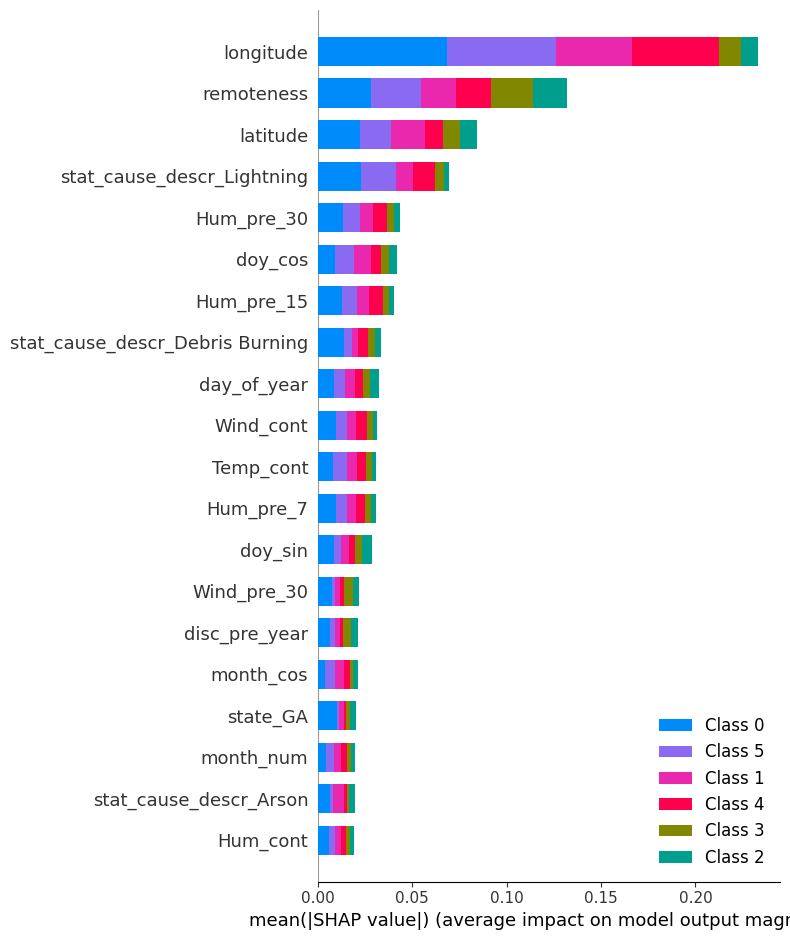

In [30]:
## summary plot 
## bar
shap.summary_plot(
    shap_values,
    X_shap_named,
    plot_type="bar"
)


### SHAP Interpretation

The SHAP summary plot shows that the model is relying on more than just weather. Longitude, remoteness, and latitude are the top three features, which show geography is playing a huge role in how the model classifies wildfire severity. This makes sense because wildfire risk is not evenly distributed across the US. Certain regions likely have more frequent or more severe fires, so the model learns location as a shortcut for risk. Remoteness also stands out, which is interesting because it may connect to response time, detection, or how quickly a fire can be contained.

Weather still matters, but it is not the only story here. Humidity, wind, temperature, and day-of-year features appear throughout the top features, which suggests the model is combining location with environmental conditions and seasonal timing.

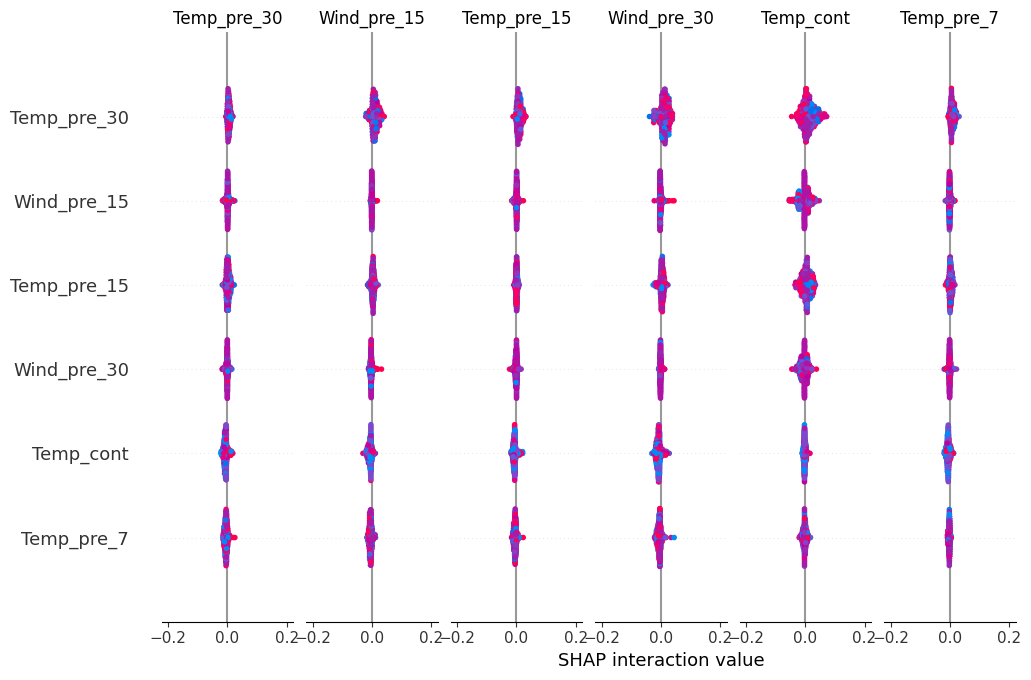

In [31]:
## interaction plot
shap.summary_plot(
    shap_values,
    X_shap_named
)

### SHAP Interaction Plot Interpretation

The SHAP interaction plot shows that temperature and wind-related variables are interacting with each other, but most of the points stay close to zero. This suggests the model is not relying on one huge interaction effect. Instead, it seems to be using several smaller signals together. The strongest interaction patterns appear around temperature before the fire, wind before the fire, and temperature at containment. That fits the wildfire context because hot and windy conditions can make fires spread faster, especially when those conditions build up before discovery. What I take from this plot is that the model is not just looking at one feature in isolation. It is using weather timing and weather combinations, but geography still seems to carry the most overall importance based on the main SHAP summary plot.

### Overall SHAP Takeaway

My main takeaway from SHAP is that this model is very geography-driven. Longitude, latitude, and remoteness matter more than I expected, which suggests the model may be learning regional wildfire patterns very strongly.

This is useful, but it also creates a possible weakness. If a severe fire happens in a location that historically looks lower-risk, the model may underestimate it. That connects back to the false negatives earlier, where some Class G fires were predicted as Class B. The weather features still support the model’s predictions, especially humidity, wind, temperature, and seasonal timing. But overall, the model seems to predict severity through a mix of where the fire happens and what the surrounding weather looks like.

## 8. Dataset Biases and Limitations

One thing that stood out to me throughout this analysis is how much the model depends on the data it was trained on. Since the dataset only includes reported US wildfires, it probably misses smaller or more remote fires that were never fully documented. Because of that, the model may learn wildfire behavior more accurately in areas where fires are reported more consistently.

The class imbalance also affects the predictions a lot. Smaller fires appear much more often in the dataset, so the model naturally becomes more confident predicting those categories. That pattern showed up repeatedly in the confusion matrix, where larger fires were often underestimated as smaller wildfire classes.

There are also important wildfire factors the model never actually sees, like terrain, fuel conditions, vegetation density, or containment response. So even though the model picks up on strong environmental and geographic patterns, it still cannot fully capture how unpredictable wildfire behavior can be.

### Interpreting These Biases

Looking back at the earlier false negatives, a lot of those failures make more sense now. The model performs best when fires match the patterns it saw most often during training. Once a fire becomes more unusual, whether that's because of location, timing, or severity. The predictions become less reliable. 

That is probably why some Class G fires were confidently predicted as Class B. The model learned the dominant wildfire patterns well, but struggled more with rare extreme events that had fewer examples in the dataset.

## 9. Final Interpretation Summary

Overall, the model did a good job capturing the relationship between environmental conditions and wildfire severity. The SHAP analysis showed that weather-related variables like temperature, humidity, and short-term conditions leading up to the fire had the biggest impact on predictions.

At the same time, the confusion matrix and false negative analysis revealed an important weakness: the model consistently struggled more with larger wildfire classes. Instead of spreading mistakes evenly across categories, it often defaulted toward smaller and more common fire classes. That pattern says a lot about both the model and the dataset itself. The model learned the dominant wildfire trends reasonably well, but it still has trouble recognizing rare, high-severity events that fall outside the patterns it saw most often during training.